### In this notebook, we want to create functions that will transform the raw audio into a deep learning input features.

In [112]:
import pydub
import librosa
import librosa.display
import os
from pydub import AudioSegment
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [14]:
# directories
mp3_audiofiles_directory = "/home/antonym/Documents/Marconi_Lab/Swahili_ASR_Model/mp3_test/"
wav_audiofiles_directory = "/home/antonym/Documents/Marconi_Lab/Swahili_ASR_Model/wav_test/"
preprocessed_Wavfiles = '/home/antonym/Documents/Marconi_Lab/Swahili_ASR_Model/preprocessed_wavfile/'

# loading the audio and  convert the mp3 audios to wav file

In [8]:
# the convertion function takes in two directory: an mp3 and wav directory
def convert_to_wav(mp3_directory, wav_directory):
    #loop through all the files in mp3 directory
    for mp3_clip in os.listdir(mp3_directory):
        #load the clips
        mp3_clips = AudioSegment.from_mp3(os.path.join(mp3_directory, mp3_clip))
        #convert the mp3 clip to wav
        # remove the last four character ".mp3" from the mp3_clip and replace it with .wav
        # and add all that to wav directory
        wav_clip = os.path.join(wav_directory, mp3_clip[:-4] + ".wav")
        #use pydub method, export to covert the mp3 to wav
        mp3_clips.export(wav_clip, format='wav')

# load the wav as an array of floating point time series values, the standardize the sampling rate, duration, number of channels of the audio

Guidelines on the sampling rate(16KHZ), number of channels (mono), and data formating requirements form [coqui website](https://stt.readthedocs.io/en/latest/DEPLOYMENT.html#model-data-match)

In [110]:
# this function takes the directory of the wav as the parameter
def resample_audio(wav_audiofiles_directory):
    
    #then we loop through the files in the directory passed to the function
    for wav_file in os.listdir(wav_audiofiles_directory):
        
        #we confirm that all are wav files
        if wav_file.endswith(".wav"):
            
            # we concatenate the input directory path and the file name to create the path of the audio file.
            input_path = os.path.join(wav_audiofiles_directory, wav_file)
            
            # Load the audio file, the number of channels and sampling rate
            samples, sample_rate = librosa.load(input_path, sr= 16000, duration= 7.00 , mono= True)
            
            #get duration
            duration = librosa.get_duration(samples)
            
             # Extract the MFCC features
            mfcc = librosa.feature.mfcc(samples, sr=sample_rate, n_mfcc=13)
            
            #visualize the wav files
            fig, ax = plt.subplots(nrows=1, sharex=False)
            librosa.display.waveshow(samples, sr=sample_rate)
            
            #this line is just useful to see whether 
            print("samples", samples, " and sample rates", sample_rate, "and duration", duration, 'seconds')
                      

# generate the mfcc of the audio

In [98]:
def generate_mfcc(wav_directory):
    for wav_file in os.listdir(wav_directory):
        
            input_path = os.path.join(wav_directory, wav_file)
            
            # Load the audio file, the number of channels and sampling rate
            samples, sample_rate = librosa.load(input_path, sr= 22050, duration= 7 , mono= True)
            
             # Extract the MFCC features
            mfcc = librosa.feature.mfcc(samples, sr=sample_rate, n_mfcc=13)
            
            return mfcc
    

# Visualize the mfcc

In [99]:
def plot_mfcc_features(mfcc_features):
    # Plot the MFCC features
    plt.imshow(mfcc_features, cmap='hot', interpolation='nearest')
    plt.title("MFCC Features")
    plt.xlabel("Frame Number")
    plt.ylabel("MFCC Coefficients")
    plt.show()
    


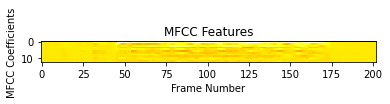

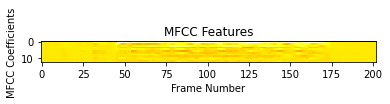

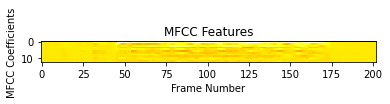

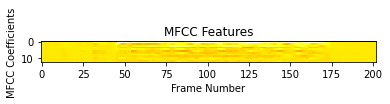

In [101]:
for wav_file in os.listdir(wav_audiofiles_directory):
    audio_clip = os.path.join(wav_audiofiles_directory, wav_file)
    mfcc_features = generate_mfcc(wav_audiofiles_directory)
    plot_mfcc_features(mfcc_features)

# call all the functions on the wav file folder

samples [0. 0. 0. ... 0. 0. 0.]  and sample rates 16000 and duration 3.3959183673469386 seconds
samples [ 0.0000000e+00  0.0000000e+00  0.0000000e+00 ...  1.6279273e-08
  5.1680087e-09 -2.0720970e-08]  and sample rates 16000 and duration 2.1681632653061222 seconds
samples [0. 0. 0. ... 0. 0. 0.]  and sample rates 16000 and duration 3.0040816326530613 seconds
samples [0. 0. 0. ... 0. 0. 0.]  and sample rates 16000 and duration 3.657142857142857 seconds


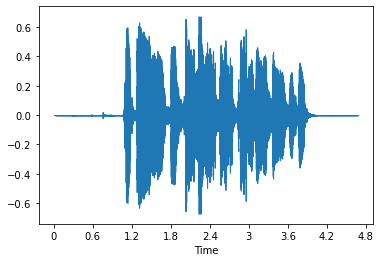

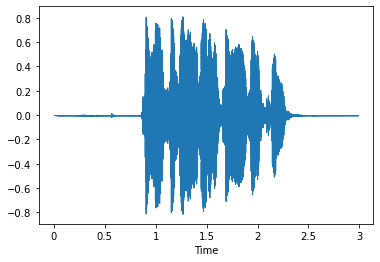

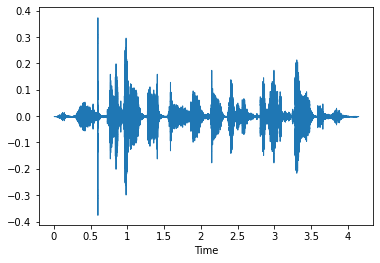

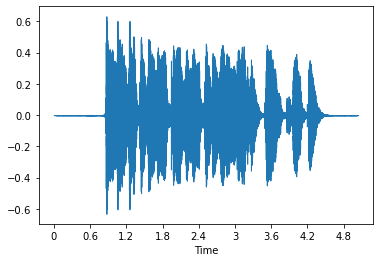

In [111]:
resample_audio(wav_audiofiles_directory)